UCI Diabetes Dataset - Logistic Regression Results:
Accuracy:  0.8250
Precision: 0.8387
Recall:    0.9286
F1 Score:  0.8814

Pima Indians Diabetes Dataset - Logistic Regression Results:
Accuracy:  0.6750
Precision: 0.7391
Recall:    0.7083
F1 Score:  0.7234


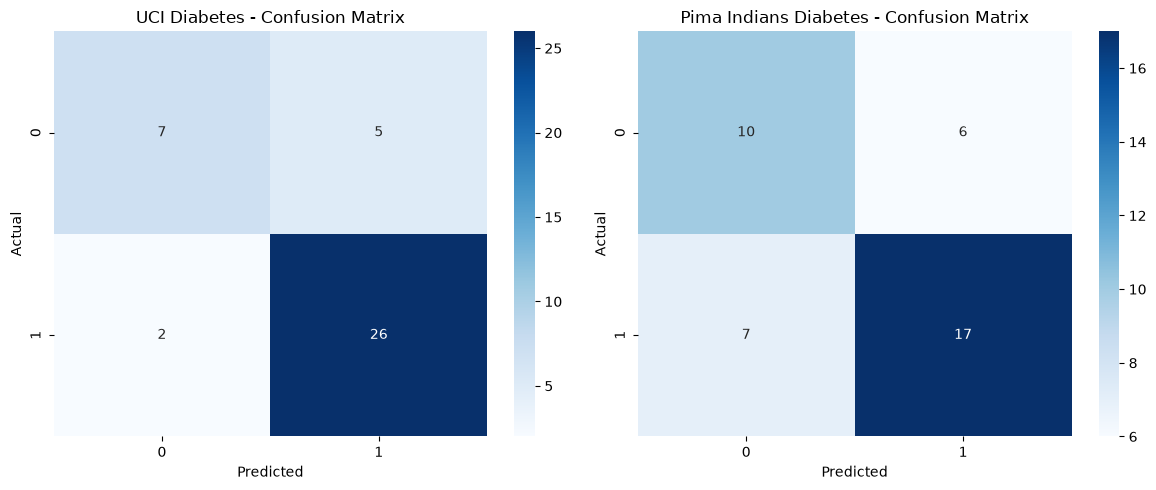

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Load the Datasets
uci_diabetes = pd.read_csv("uci_diabetes (3).csv")
pima_diabetes = pd.read_csv("pima_diabetes (3).csv")

# Select Features and Target Variable
features = ["Glucose", "BloodPressure", "BMI"]
target = "Outcome"

# UCI Dataset
X_uci = uci_diabetes[features]
y_uci = uci_diabetes[target]

# Pima Dataset
X_pima = pima_diabetes[features]
y_pima = pima_diabetes[target]

# Split Data into Training and Testing Sets (80%-20%)
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci,
    y_uci,
    test_size=0.2,
    random_state=42
)

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima,
    y_pima,
    test_size=0.2,
    random_state=42
)

# Train Logistic Regression Model
model_uci = LogisticRegression(max_iter=1000)
model_uci.fit(X_train_uci, y_train_uci)

model_pima = LogisticRegression(max_iter=1000)
model_pima.fit(X_train_pima, y_train_pima)

# Make Predictions
y_pred_uci = model_uci.predict(X_test_uci)
y_pred_pima = model_pima.predict(X_test_pima)

# Evaluate UCI Model
accuracy_uci = accuracy_score(y_test_uci, y_pred_uci)
precision_uci = precision_score(y_test_uci, y_pred_uci, zero_division=0)
recall_uci = recall_score(y_test_uci, y_pred_uci, zero_division=0)
f1_uci = f1_score(y_test_uci, y_pred_uci, zero_division=0)

# Evaluate Pima Model
accuracy_pima = accuracy_score(y_test_pima, y_pred_pima)
precision_pima = precision_score(y_test_pima, y_pred_pima, zero_division=0)
recall_pima = recall_score(y_test_pima, y_pred_pima, zero_division=0)
f1_pima = f1_score(y_test_pima, y_pred_pima, zero_division=0)

# Display Results
print("UCI Diabetes Dataset - Logistic Regression Results:")
print(f"Accuracy:  {accuracy_uci:.4f}")
print(f"Precision: {precision_uci:.4f}")
print(f"Recall:    {recall_uci:.4f}")
print(f"F1 Score:  {f1_uci:.4f}")

print("\nPima Indians Diabetes Dataset - Logistic Regression Results:")
print(f"Accuracy:  {accuracy_pima:.4f}")
print(f"Precision: {precision_pima:.4f}")
print(f"Recall:    {recall_pima:.4f}")
print(f"F1 Score:  {f1_pima:.4f}")

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# UCI Confusion Matrix
sns.heatmap(
    confusion_matrix(y_test_uci, y_pred_uci),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("UCI Diabetes - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Pima Confusion Matrix
sns.heatmap(
    confusion_matrix(y_test_pima, y_pred_pima),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title("Pima Indians Diabetes - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()